In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from collections import deque
import pandas as pd

# ------------------------
# PARAMETERS
# ------------------------
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 5000
NUM_PARTIES = 2
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS
NUM_RUNS = 30

NUM_CITIES = 8

CITY_INTENSITY = (10, 30)
CITY_SPREAD = (20, 60)

np.random.seed(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

PARTY_BIAS = [0.45, 0.55]

# ------------------------
# GENERATE DENSITY FIELD
# ------------------------
density = np.full((HEIGHT, WIDTH), 1.0)
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))

for _ in range(NUM_CITIES):
    cx = np.random.uniform(0, WIDTH)
    cy = np.random.uniform(0, HEIGHT)
    intensity = np.random.uniform(*CITY_INTENSITY)
    sigma = np.random.uniform(*CITY_SPREAD)
    density += intensity * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

flat_density = density.ravel()
flat_density /= flat_density.sum()

indices = np.random.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat_density)
voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))

# ------------------------
# PARTY ASSIGNMENT
# ------------------------
voter_parties = np.random.choice(
    np.arange(NUM_PARTIES),
    size=NUM_VOTERS,
    p=PARTY_BIAS
)

# ------------------------
# ADJACENCY GRAPH (kNN)
# ------------------------

def build_adjacency(voters, k=25):
    tree = cKDTree(voters)
    adjacency = {}

    for i in range(len(voters)):
        _, idx = tree.query(voters[i], k=k+1)
        adjacency[i] = set(idx[1:])

    return adjacency

adjacency = build_adjacency(voters, k=25)

# ------------------------
# SEED SELECTION
# ------------------------
def pick_seeds(n_nodes, num_districts, rng):
    return rng.choice(n_nodes, size=num_districts, replace=False)

# ------------------------
# CONNECTED DISTRICT GROWTH (FIXED)
# ------------------------
def grow_district(seed, adjacency, assigned, max_size, rng,
                   voter_parties=None,
                   target_party=None,
                   bias_strength=0.0):

    district = set([seed])
    queue = deque([seed])
    visited = set([seed])

    while queue and len(district) < max_size:
        node = queue.popleft()

        neighbors = list(adjacency[node])

        # ------------------------
        # BIASED EXPANSION
        # ------------------------
        if target_party is not None and bias_strength > 0:
            def score(nbr):
                is_target = (voter_parties[nbr] == target_party)
                return bias_strength * is_target + (1 - bias_strength) * rng.random()

            neighbors = sorted(neighbors, key=score, reverse=True)
        else:
            rng.shuffle(neighbors)

        for nbr in neighbors:
            if nbr not in visited and not assigned[nbr]:
                visited.add(nbr)
                district.add(nbr)
                queue.append(nbr)

                if len(district) >= max_size:
                    break

    for n in district:
        assigned[n] = True

    return district

# ------------------------
# MAIN DISTRICTING FUNCTION (FIXED)
# ------------------------
def connected_districts(voters, adjacency, num_districts, rng,
                        voter_parties,
                        target_size=None,
                        tolerance=0.15,
                        target_party=None,
                        bias_strength=0.0):

    n = len(voters)

    if target_size is None:
        target_size = n // num_districts

    seeds = pick_seeds(n, num_districts, rng)

    assigned = np.zeros(n, dtype=bool)
    districts = []

    # ------------------------
    # GROW INITIAL DISTRICTS
    # ------------------------
    for seed in seeds:
        if assigned[seed]:
            continue

        district = grow_district(
            seed,
            adjacency,
            assigned,
            target_size,
            rng,
            voter_parties=voter_parties,
            target_party=target_party,
            bias_strength=bias_strength
        )

        districts.append(district)

    # ------------------------
    # HANDLE LEFTOVERS
    # ------------------------
    unassigned = [i for i in range(n) if not assigned[i]]

    for node in unassigned:
        neighbor_districts = []

        for nbr in adjacency[node]:
            for d_id, d in enumerate(districts):
                if nbr in d:
                    neighbor_districts.append(d_id)

        if neighbor_districts:
            chosen = max(set(neighbor_districts), key=neighbor_districts.count)
        else:
            chosen = rng.integers(len(districts))

        districts[chosen].add(node)
        assigned[node] = True

    labels = np.zeros(n, dtype=int)

    for d_id, district in enumerate(districts):
        for node in district:
            labels[node] = d_id

    return labels

# ------------------------
# VOTE COUNTING (FIXED)
# ------------------------
def count_votes(district_labels, voter_parties):
    districts = [
        {party: 0 for party in PARTY_IDS}
        for _ in range(NUM_DISTRICTS)
    ]

    for i, d in enumerate(district_labels):
        party = PARTY_IDS[voter_parties[i]]
        districts[d][party] += 1

    return districts

# ------------------------
# SIMULATION
# ------------------------
fair_wasted_vote_table = []
gerry_wasted_vote_table = []

for run in range(NUM_RUNS):
    rng = np.random.default_rng(run)

    # -------------------------
    # FAIR
    # -------------------------
    fair_labels = connected_districts(
        voters, adjacency, NUM_DISTRICTS, rng,
        voter_parties=voter_parties,
        target_size=VOTERS_PER_DISTRICT,
        tolerance=0.15
    )

    fair_counts = count_votes(fair_labels, voter_parties)

    fair_wasted_votes = {p: 0 for p in PARTY_IDS}
    total_votes = 0

    for district in fair_counts:
        district_total = sum(district.values())
        total_votes += district_total

        winner = max(district, key=district.get)
        winner_votes = district[winner]

        next_highest = max([v for p, v in district.items() if p != winner])

        excess = winner_votes - (next_highest + 1)

        for p in PARTY_IDS:
            votes = district[p]
            fair_wasted_votes[p] += excess if p == winner else votes

    fair_row = {"Run": run + 1}
    fair_row.update({p: fair_wasted_votes[p] / total_votes for p in PARTY_IDS})
    fair_wasted_vote_table.append(fair_row)

    # -------------------------
    # GERRYMANDERED
    # -------------------------
    biased_labels = connected_districts(
        voters, adjacency, NUM_DISTRICTS, rng,
        voter_parties=voter_parties,
        target_size=VOTERS_PER_DISTRICT,
        tolerance=0.15,
        target_party=0,
        bias_strength=0.95
    )

    gerry_counts = count_votes(biased_labels, voter_parties)

    gerry_wasted_votes = {p: 0 for p in PARTY_IDS}
    total_votes = 0

    for district in gerry_counts:
        district_total = sum(district.values())
        total_votes += district_total

        winner = max(district, key=district.get)
        winner_votes = district[winner]

        next_highest = max([v for p, v in district.items() if p != winner])

        excess = winner_votes - (next_highest + 1)

        for p in PARTY_IDS:
            votes = district[p]
            gerry_wasted_votes[p] += excess if p == winner else votes

    gerry_row = {"Run": run + 1}
    gerry_row.update({p: gerry_wasted_votes[p] / total_votes for p in PARTY_IDS})
    gerry_wasted_vote_table.append(gerry_row)

# ------------------------
# RESULTS
# ------------------------
df_fair = pd.DataFrame(fair_wasted_vote_table)
df_gerry = pd.DataFrame(gerry_wasted_vote_table)

print("\n--- FAIR DISTRICTS ---")
print(df_fair.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n--- FAIR MEAN ---")
print(df_fair.drop(columns="Run").mean())

print("\n--- GERRYMANDERED DISTRICTS ---")
print(df_gerry.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n--- GERRYMANDERED MEAN ---")
print(df_gerry.drop(columns="Run").mean())


--- FAIR DISTRICTS ---
 Run  Party 0  Party 1
   1   0.4470   0.1040
   2   0.4470   0.1040
   3   0.4468   0.1042
   4   0.4468   0.1042
   5   0.4468   0.1042
   6   0.4470   0.1040
   7   0.4468   0.1042
   8   0.4468   0.1042
   9   0.4468   0.1042
  10   0.4470   0.1040
  11   0.4468   0.1042
  12   0.4468   0.1042
  13   0.4470   0.1040
  14   0.4470   0.1040
  15   0.4468   0.1042
  16   0.4468   0.1042
  17   0.4470   0.1040
  18   0.4470   0.1040
  19   0.4470   0.1040
  20   0.4468   0.1042
  21   0.4466   0.1044
  22   0.4468   0.1042
  23   0.4468   0.1042
  24   0.4468   0.1042
  25   0.4470   0.1040
  26   0.4468   0.1042
  27   0.4472   0.1038
  28   0.4470   0.1040
  29   0.4466   0.1044
  30   0.4468   0.1042

--- FAIR MEAN ---
Party 0    0.446873
Party 1    0.104127
dtype: float64

--- GERRYMANDERED DISTRICTS ---
 Run  Party 0  Party 1
   1   0.4468   0.1042
   2   0.4472   0.1038
   3   0.4470   0.1040
   4   0.4466   0.1044
   5   0.4468   0.1042
   6   0.4472   0.

In [6]:
# ============================================================
# METRIC FUNCTIONS
# ============================================================

def compute_efficiency_gap(district_counts):
    """
    N-party efficiency gap using next-highest + 1 as the win threshold.
    Winner wastes votes beyond (runner-up + 1); losers waste all votes.
    Returns eg_value, majority_party, wasted_votes dict, total_votes.
    """
    wasted_votes = {party: 0 for party in PARTY_IDS}
    total_votes = 0

    for district in district_counts:
        district_total = sum(district.values())
        total_votes += district_total

        sorted_parties = sorted(district.items(), key=lambda x: x[1], reverse=True)
        winner, winner_votes = sorted_parties[0]
        runner_up_votes = sorted_parties[1][1] if len(sorted_parties) > 1 else 0
        needed_to_win = runner_up_votes + 1

        for party, votes in district.items():
            if party == winner:
                wasted_votes[party] += max(0, votes - needed_to_win)
            else:
                wasted_votes[party] += votes

    majority_party = max(wasted_votes, key=wasted_votes.get)
    others_wasted = sum(v for p, v in wasted_votes.items() if p != majority_party)
    eg_value = (wasted_votes[majority_party] - others_wasted) / total_votes

    return {
        "eg_value":       eg_value,
        "majority_party": majority_party,
        "wasted_votes":   wasted_votes,
        "total_votes":    total_votes
    }


# ------------------------------------------------------------

def get_is_winner(district, target_party):
    target_votes = district[target_party]
    return all(target_votes > district[p] for p in district if p != target_party)

def get_current_vote_share(district_counts, target_party):
    total      = sum(sum(d.values()) for d in district_counts)
    party_total = sum(d[target_party] for d in district_counts)
    return party_total / total

def simulate_vote_shifts_forward(district_counts, target_party):
    counts      = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    n_comp      = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            active = sorted([p for p in competitors if d[p] > 0],
                            key=lambda p: (d[p], p))
            if active:
                taken = min(d[active[0]], n_comp)
                if taken > 0:
                    d[active[0]]    -= taken
                    d[target_party] += taken
                    any_shift = True

        new_wins = count_wins()
        if new_wins > current_wins:
            vs = (sum(d[target_party] for d in counts) /
                  sum(sum(d.values()) for d in counts))
            history.append({"districts_won": new_wins, "vote_share": vs})
            current_wins = new_wins

        if not any_shift or new_wins == NUM_DISTRICTS:
            break

    return history

def simulate_vote_shifts_backward(district_counts, target_party):
    counts      = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    n_comp      = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            ranked   = sorted(competitors, key=lambda p: (d[p], p), reverse=True)
            to_move  = min(d[target_party], n_comp)
            if to_move > 0:
                d[target_party]  -= to_move
                d[ranked[0]]     += to_move
                any_shift = True

        new_wins = count_wins()
        if new_wins < current_wins:
            vs = (sum(d[target_party] for d in counts) /
                  sum(sum(d.values()) for d in counts))
            history.append({"districts_won": new_wins, "vote_share": vs})
            current_wins = new_wins

        if not any_shift or new_wins == 0:
            break

    return history

def compute_step_curve_for_party(district_counts, target_party):
    base = (get_current_vote_share(district_counts, target_party),
            sum(1 for d in district_counts if get_is_winner(d, target_party)))

    fwd = simulate_vote_shifts_forward(district_counts, target_party)
    rev = simulate_vote_shifts_backward(district_counts, target_party)

    pts = ([base]
           + [(h["vote_share"], h["districts_won"]) for h in fwd]
           + [(h["vote_share"], h["districts_won"]) for h in rev])
    return sorted(set(pts))

def compute_pairwise_area(curve1, curve2):
    """
    Area between the seat-vote curves of two parties.
    Near 0 = symmetric treatment; larger = structural bias between the pair.
    """
    x1, y1 = zip(*sorted(curve1))
    x2, y2 = zip(*sorted(curve2))
    y1 = np.array(y1) / NUM_DISTRICTS
    y2 = np.array(y2) / NUM_DISTRICTS

    all_x = np.unique(np.concatenate([x1, x2]))
    if all_x[0]  > 0: all_x = np.insert(all_x, 0, 0.0)
    if all_x[-1] < 1: all_x = np.append(all_x, 1.0)

    def get_val(x, xs, ys):
        return ys[max(0, np.searchsorted(xs, x, side='right') - 1)]

    area = 0.0
    for i in range(len(all_x) - 1):
        mid   = (all_x[i] + all_x[i+1]) / 2
        width = all_x[i+1] - all_x[i]
        area += width * abs(get_val(mid, x1, y1) - get_val(mid, x2, y2))
    return area

In [7]:
# ============================================================
# SIMULATION: fair vs gerrymandered, NUM_RUNS iterations
# ============================================================
import itertools

party_pairs = list(itertools.combinations(PARTY_IDS, 2))

fair_eg_rows    = []
gerry_eg_rows   = []
fair_pair_rows  = []
gerry_pair_rows = []

for run in range(NUM_RUNS):
    rng = np.random.default_rng(run)

    # ── FAIR ──────────────────────────────────────────────
    fair_labels = connected_districts(
        voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT, rng)
    fair_counts = count_votes(fair_labels)

    f_eg = compute_efficiency_gap(fair_counts)
    fair_eg_rows.append({
        "Run": run + 1,
        "EG_Value": f_eg["eg_value"],
        "Majority_Party": f_eg["majority_party"],
        **{f"Wasted_{p}": f_eg["wasted_votes"][p] for p in PARTY_IDS}
    })

    f_curves = {p: compute_step_curve_for_party(fair_counts, p) for p in PARTY_IDS}
    for p1, p2 in party_pairs:
        fair_pair_rows.append({
            "Run": run + 1,
            "Comparison": f"{p1} vs {p2}",
            "Pairwise_Area": compute_pairwise_area(f_curves[p1], f_curves[p2])
        })

    # ── GERRYMANDERED (Party 0 favored) ───────────────────
    gerry_labels = connected_districts(
        voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT, rng,
        bias_party=0)                          # adjust arg name to match your function
    gerry_counts = count_votes(gerry_labels)

    g_eg = compute_efficiency_gap(gerry_counts)
    gerry_eg_rows.append({
        "Run": run + 1,
        "EG_Value": g_eg["eg_value"],
        "Majority_Party": g_eg["majority_party"],
        **{f"Wasted_{p}": g_eg["wasted_votes"][p] for p in PARTY_IDS}
    })

    g_curves = {p: compute_step_curve_for_party(gerry_counts, p) for p in PARTY_IDS}
    for p1, p2 in party_pairs:
        gerry_pair_rows.append({
            "Run": run + 1,
            "Comparison": f"{p1} vs {p2}",
            "Pairwise_Area": compute_pairwise_area(g_curves[p1], g_curves[p2])
        })

    print(f"Run {run + 1}/{NUM_RUNS} complete.")

# ── DataFrames ────────────────────────────────────────────
df_fair_eg    = pd.DataFrame(fair_eg_rows)
df_gerry_eg   = pd.DataFrame(gerry_eg_rows)
df_fair_pair  = pd.DataFrame(fair_pair_rows)
df_gerry_pair = pd.DataFrame(gerry_pair_rows)

# ── Print summaries ───────────────────────────────────────
print("\n========== EFFICIENCY GAP ==========")
print("\n-- Fair: per run --")
print(df_fair_eg.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n-- Fair: mean --")
print(df_fair_eg[["EG_Value"] + [f"Wasted_{p}" for p in PARTY_IDS]].mean())

print("\n-- Gerrymandered: per run --")
print(df_gerry_eg.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n-- Gerrymandered: mean --")
print(df_gerry_eg[["EG_Value"] + [f"Wasted_{p}" for p in PARTY_IDS]].mean())

print("\n========== PAIRWISE PARTISAN SYMMETRY ==========")
print("\n-- Fair: mean by comparison --")
print(df_fair_pair.groupby("Comparison")["Pairwise_Area"].agg(["mean","std"]))
print("\n-- Gerrymandered: mean by comparison --")
print(df_gerry_pair.groupby("Comparison")["Pairwise_Area"].agg(["mean","std"]))

# ── Histograms: Efficiency Gap ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Efficiency Gap: Fair vs Gerrymandered", fontsize=14)

for ax, df, color, title in zip(
    axes,
    [df_fair_eg, df_gerry_eg],
    ["steelblue", "tomato"],
    ["Fair Districts", "Gerrymandered Districts"]
):
    mean_val = df["EG_Value"].mean()
    ax.hist(df["EG_Value"], bins=15, color=color, edgecolor="black", alpha=0.7)
    ax.axvline(mean_val, color="black", linestyle="--", lw=2,
               label=f"Mean = {mean_val:.4f}")
    ax.set_title(title)
    ax.set_xlabel("Efficiency Gap")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ── Histograms: Pairwise Partisan Symmetry ────────────────
n_pairs = len(party_pairs)
fig, axes = plt.subplots(1, n_pairs, figsize=(7 * n_pairs, 5))
if n_pairs == 1:
    axes = [axes]

fig.suptitle("Pairwise Partisan Symmetry: Fair vs Gerrymandered", fontsize=14)

for ax, (p1, p2) in zip(axes, party_pairs):
    comp       = f"{p1} vs {p2}"
    fair_vals  = df_fair_pair [df_fair_pair ["Comparison"] == comp]["Pairwise_Area"]
    gerry_vals = df_gerry_pair[df_gerry_pair["Comparison"] == comp]["Pairwise_Area"]

    bins = np.linspace(min(fair_vals.min(), gerry_vals.min()),
                       max(fair_vals.max(), gerry_vals.max()), 16)

    ax.hist(fair_vals,  bins=bins, alpha=0.6, color="steelblue",
            edgecolor="black", label="Fair")
    ax.hist(gerry_vals, bins=bins, alpha=0.6, color="tomato",
            edgecolor="black", label="Gerrymandered")
    ax.axvline(fair_vals.mean(),  color="steelblue", linestyle="--", lw=2,
               label=f"Fair mean = {fair_vals.mean():.4f}")
    ax.axvline(gerry_vals.mean(), color="tomato",    linestyle="--", lw=2,
               label=f"Gerry mean = {gerry_vals.mean():.4f}")

    ax.set_title(comp)
    ax.set_xlabel("Pairwise Area")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

TypeError: connected_districts() missing 1 required positional argument: 'voter_parties'

# Spatial Gerrymandering Simulation — Documentation

## Overview

This simulation generates a synthetic population distributed over a 2D region, assigns voters to political parties, constructs a spatial adjacency graph, and partitions voters into connected electoral districts. It then computes **wasted vote ratios** to evaluate electoral fairness under repeated randomized runs.

The model compares:
- Random (fair) connected districting
- Intended partisan-biased districting (currently not fully implemented)

---

# 1. Synthetic Population Generation

## Spatial domain

- Width: `WIDTH = 380`
- Height: `HEIGHT = 280`
- Voters: `NUM_VOTERS = 1000`

---

## Density field (cities)

Population density is defined as:

$$
\rho(x,y) = 1 + \sum_{i=1}^{N_c} A_i \exp\left(-\frac{(x-x_i)^2 + (y-y_i)^2}{2\sigma_i^2}\right)
$$

where:
- $N_c = 8$
- $A_i$ = city intensity
- $\sigma_i$ = spatial spread

---

## Sampling voters

Voters are sampled from the normalized density:

$$
P(x,y) = \frac{\rho(x,y)}{\sum_{x,y} \rho(x,y)}
$$

Each voter is a coordinate:

$$
v_i = (x_i, y_i), \quad i = 1, \dots, 1000
$$

---

# 2. Party Assignment

Each voter is assigned to one of three parties:

$$
P(\text{party} = k) = \pi_k
$$

with:

$$
\pi = (0.35, 0.45, 0.20)
$$

---

# 3. Spatial Adjacency Graph

A k-nearest neighbor graph is constructed:

$$
\mathcal{N}_k(i)
$$

with $k = 25$.

This defines a graph:

$$
G = (V, E)
$$

where:
- $V$ = voters
- $E$ = spatial proximity edges

---

# 4. District Formation

## Seed selection

Randomly choose:

$$
D = 8 \text{ seeds}
$$

---

## Growth process

Each district grows via BFS-like expansion:

A node is added if:
- It is a neighbor in $\mathcal{N}_k$
- It is unassigned
- District size constraint is satisfied

---

## Size constraint

$$
S_{\max} = (1 + \tau)\frac{N}{D}
$$

where:
- $N = 1000$
- $D = 8$
- $\tau = 0.15$

---

## Algorithm behavior

- Start from seed
- Expand via shuffled neighbor order
- Stop at max size
- Ensure connectivity

---

# 5. Leftover Assignment

Unassigned nodes are assigned based on neighbor majority:

- Check kNN neighbors
- Identify district membership frequency
- Assign to most common district

If no assigned neighbors exist:
- assign randomly

---

# 6. District Labels

Each voter receives a label:

$$
L_i \in \{0, 1, \dots, D-1\}
$$

---

# 7. Visualization

Each pixel is assigned the label of its nearest voter, producing a full spatial map.

Outputs show:
- District boundaries
- Voter party distribution

---

# 8. Vote Counting

For each district $d$:

$$
V_{d,p}
$$

represents votes for party $p$.

---

## Winner

$$
p^* = \arg\max_p V_{d,p}
$$

---

## Wasted votes

### Winner wasted votes:

$$
W_{\text{winner}} = V_{d,p^*} - (V_{d,p^{(2)}} + 1)
$$

### Loser wasted votes:

$$
W_{\text{loser}} = V_{d,p}, \quad p \neq p^*
$$

---

## Wasted vote ratio

$$
R_p = \frac{\sum_d W_{d,p}}{\sum_d \sum_p V_{d,p}}
$$

---

# 9. Simulation Loop

The simulation runs:

$$
N_{\text{runs}} = 10
$$

Each run:
1. Generate districts
2. Count votes
3. Compute wasted vote ratios

---

# 10. Output

Produces:
- Per-run wasted vote table
- Mean wasted vote ratios across runs

---

# 11. Limitations

## Biased districting not implemented

Parameters:
- `target_party`
- `bias_strength`

are currently unused.

## Missing function

`count_votes()` is required but not included.

## Stochastic variation

District shapes vary due to:
- random seeds
- randomized BFS traversal

---

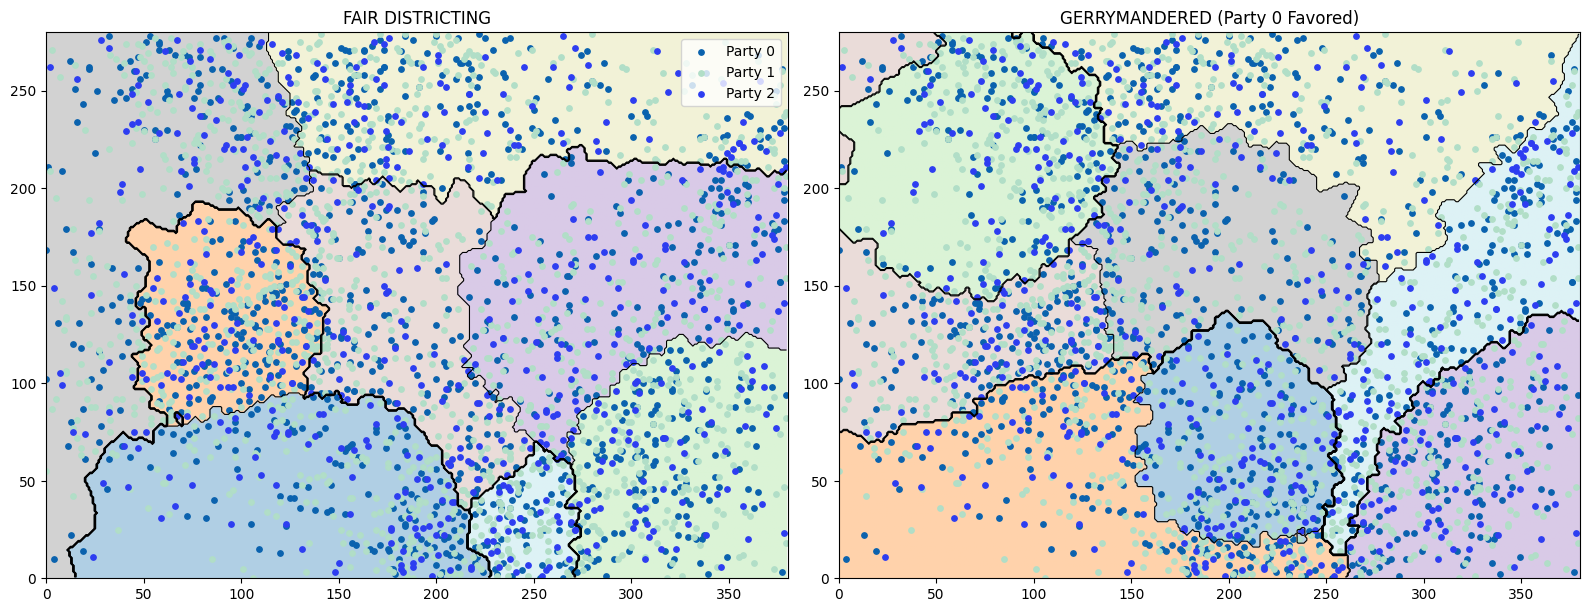

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# ------------------------
# PARAMETERS
# ------------------------
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 3000
NUM_PARTIES = 3
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS

rng = np.random.default_rng(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

# ------------------------
# POPULATION DENSITY (YOUR ORIGINAL IDEA RESTORED)
# ------------------------
density = np.ones((HEIGHT, WIDTH))
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))

NUM_CITIES = 8
CITY_INTENSITY = (10, 30)
CITY_SPREAD = (20, 60)

for _ in range(NUM_CITIES):
    cx = rng.uniform(0, WIDTH)
    cy = rng.uniform(0, HEIGHT)
    intensity = rng.uniform(*CITY_INTENSITY)
    sigma = rng.uniform(*CITY_SPREAD)

    density += intensity * np.exp(
        -((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2)
    )

flat = density.ravel()
flat /= flat.sum()

indices = rng.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat)

voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))

# ------------------------
# PARTY PREFERENCES
# ------------------------
PARTY_BIAS = [0.35, 0.45, 0.20]

voter_parties = rng.choice(
    np.arange(NUM_PARTIES),
    size=NUM_VOTERS,
    p=PARTY_BIAS
)

# ------------------------
# DISTRICT GROWTH (CONNECTED BFS)
# ------------------------
def grow_district(seed, d_id, district, unassigned, tree):

    queue = [seed]
    district[seed] = d_id
    unassigned.remove(seed)
    count = 1

    while queue and count < VOTERS_PER_DISTRICT:

        current = queue.pop(0)

        _, neighbors = tree.query(voters[current], k=40)
        neighbors = np.atleast_1d(neighbors)
        neighbors = rng.permutation(neighbors)

        for n in neighbors:
            if n in unassigned:
                district[n] = d_id
                unassigned.remove(n)
                queue.append(n)
                count += 1
                if count >= VOTERS_PER_DISTRICT:
                    break

    return district, unassigned

# ------------------------
# BUILD DISTRICTS (FAIR OR GERRYMANDERED)
# ------------------------
def build_districts(voters, bias_party=None):

    N = len(voters)
    district = -np.ones(N, dtype=int)
    unassigned = set(range(N))
    tree = cKDTree(voters)

    for d in range(NUM_DISTRICTS):

        if not unassigned:
            break

        seed = rng.choice(list(unassigned))

        # ------------------------
        # GERRYMANDER SEED BIAS
        # ------------------------
        if bias_party is not None:
            biased = [i for i in unassigned if voter_parties[i] == bias_party]
            if biased:
                seed = rng.choice(biased)

        district, unassigned = grow_district(seed, d, district, unassigned, tree)

    # ------------------------
    # LEFTOVERS (YOUR SIMPLE RULE)
    # ------------------------
    leftover = np.where(district == -1)[0]
    assigned = np.where(district != -1)[0]

    if len(leftover) > 0:
        assigned_tree = cKDTree(voters[assigned])

        for i in leftover:
            _, idx = assigned_tree.query(voters[i])
            district[i] = district[assigned[idx]]

    return district

# ------------------------
# VOTE COUNT
# ------------------------
def count_votes(district_labels):

    district_counts = []

    for d in range(NUM_DISTRICTS):
        mask = district_labels == d
        counts = {p: 0 for p in PARTY_IDS}

        for i in np.where(mask)[0]:
            counts[PARTY_IDS[voter_parties[i]]] += 1

        district_counts.append(counts)

    return district_counts

# ------------------------
# VISUALIZATION
# ------------------------
def plot_map(ax, district_labels, title):

    tree = cKDTree(voters)

    xx, yy = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))
    grid = np.column_stack((xx.ravel(), yy.ravel()))

    _, nn = tree.query(grid)
    pixel = district_labels[nn].reshape((HEIGHT, WIDTH))

    ax.imshow(pixel, origin='lower', cmap='tab20', alpha=0.35)

    ax.contour(
        pixel,
        levels=np.arange(NUM_DISTRICTS) + 0.5,
        colors='black',
        linewidths=0.8,
        origin='lower'
    )

    for i, p in enumerate(PARTY_IDS):
        mask = voter_parties == i
        ax.scatter(
            voters[mask, 0],
            voters[mask, 1],
            s=15,
            color=PARTY_COLORS[p],
            label=p
        )

    ax.set_title(title)
    ax.set_xlim(0, WIDTH)
    ax.set_ylim(0, HEIGHT)

# ------------------------
# BUILD BOTH MAPS
# ------------------------
fair = build_districts(voters, bias_party=None)
gerry = build_districts(voters, bias_party=0)

# ------------------------
# PLOT
# ------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_map(axes[0], fair, "FAIR DISTRICTING")
plot_map(axes[1], gerry, "GERRYMANDERED (Party 0 Favored)")

axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:

# ------------------------
# PLOT
# ------------------------
def plot_map(labels, title):
    tree = cKDTree(voters)

    xx, yy = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))
    grid = np.column_stack((xx.ravel(), yy.ravel()))

    _, nn = tree.query(grid)
    pixel = labels[nn].reshape((HEIGHT, WIDTH))

    plt.figure(figsize=(10, 7))
    plt.imshow(pixel, origin='lower', cmap='tab20', alpha=0.35)

    plt.contour(pixel,
                 levels=np.arange(NUM_DISTRICTS) + 0.5,
                 colors='black',
                 linewidths=1,
                 origin='lower')

    for i, p in enumerate(PARTY_IDS):
        mask = voter_parties == i
        plt.scatter(voters[mask, 0], voters[mask, 1],
                    s=15, label=p, color=PARTY_COLORS[p])

    plt.title(title)
    plt.legend()
    plt.show()


In [ ]:
print(np.bincount(district_labels))

NameError: name 'district_labels' is not defined

Run 1/30 complete.
Run 2/30 complete.
Run 3/30 complete.
Run 4/30 complete.
Run 5/30 complete.
Run 6/30 complete.
Run 7/30 complete.
Run 8/30 complete.
Run 9/30 complete.
Run 10/30 complete.
Run 11/30 complete.
Run 12/30 complete.
Run 13/30 complete.
Run 14/30 complete.
Run 15/30 complete.
Run 16/30 complete.
Run 17/30 complete.
Run 18/30 complete.
Run 19/30 complete.
Run 20/30 complete.
Run 21/30 complete.
Run 22/30 complete.
Run 23/30 complete.
Run 24/30 complete.
Run 25/30 complete.
Run 26/30 complete.
Run 27/30 complete.
Run 28/30 complete.
Run 29/30 complete.
Run 30/30 complete.

--- FAIR DISTRICTS ---
 Run  Party 0  Party 1
   1   0.4474   0.1036
   2   0.4474   0.1036
   3   0.4474   0.1036
   4   0.4474   0.1036
   5   0.4474   0.1036
   6   0.4474   0.1036
   7   0.4474   0.1036
   8   0.4474   0.1036
   9   0.4474   0.1036
  10   0.4474   0.1036
  11   0.4464   0.1048
  12   0.4474   0.1036
  13   0.4474   0.1036
  14   0.4474   0.1036
  15   0.4474   0.1036
  16   0.4474   0

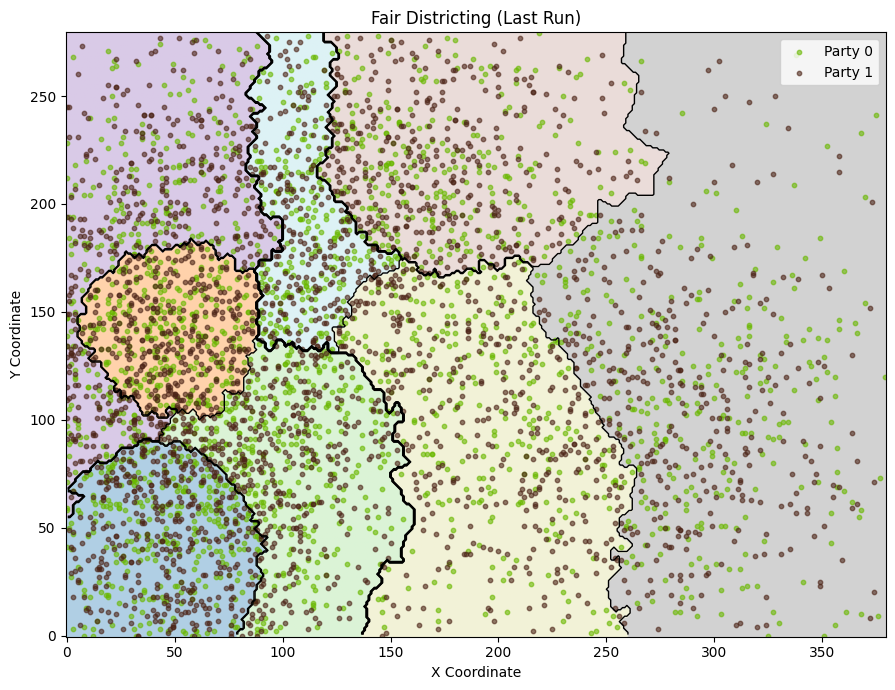

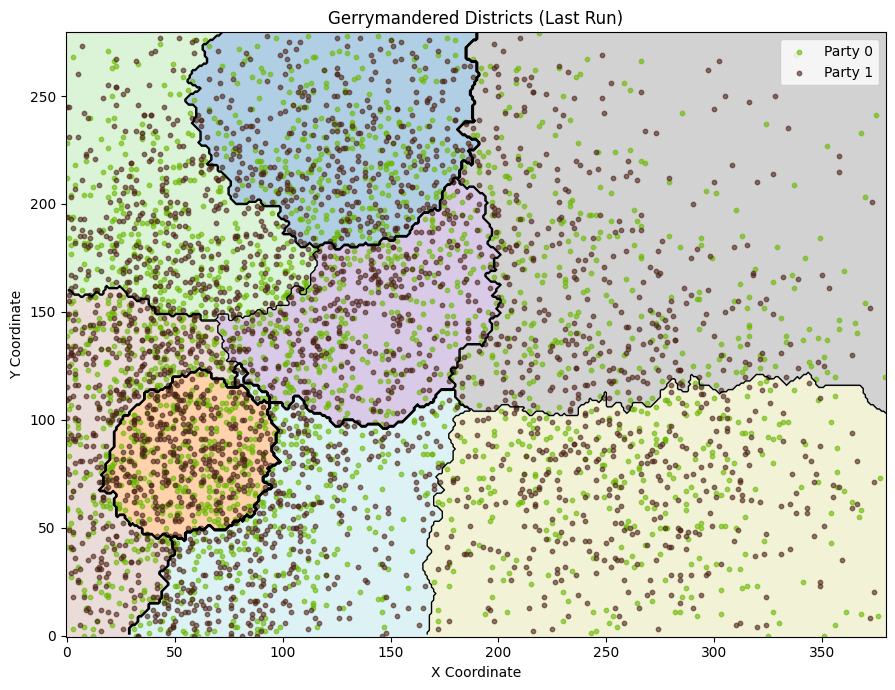

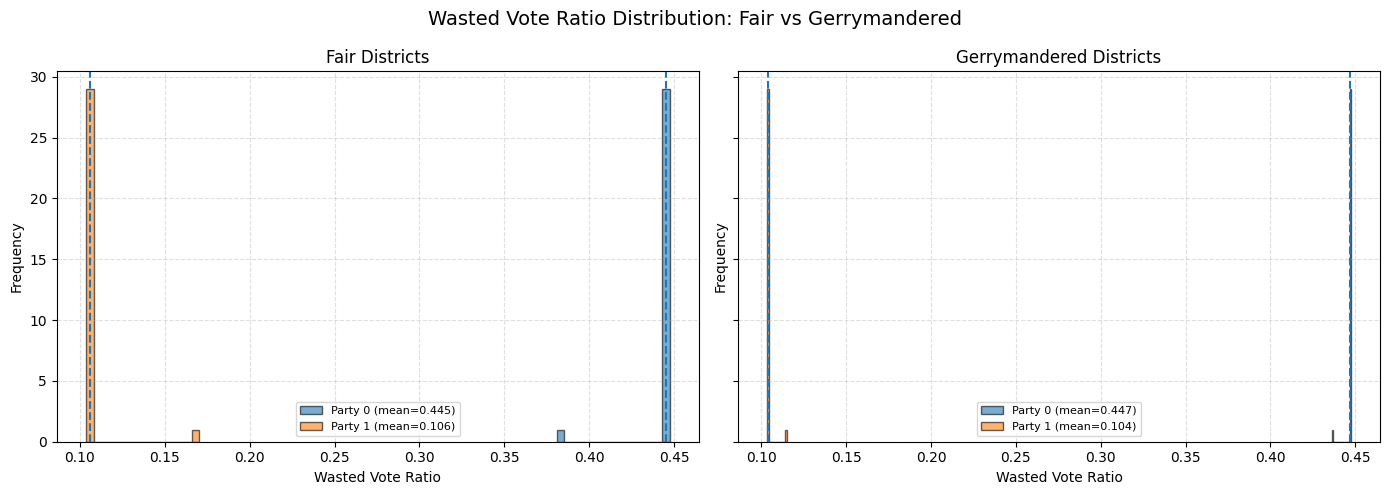

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from collections import deque
import pandas as pd

# ------------------------
# PARAMETERS
# ------------------------
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 5000
NUM_PARTIES = 2
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS
NUM_RUNS = 30

NUM_CITIES = 8
CITY_INTENSITY = (10, 30)
CITY_SPREAD = (20, 60)

np.random.seed(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

PARTY_BIAS = [0.45, 0.55]

# ------------------------
# GENERATE DENSITY FIELD
# ------------------------
density = np.full((HEIGHT, WIDTH), 1.0)
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))

for _ in range(NUM_CITIES):
    cx = np.random.uniform(0, WIDTH)
    cy = np.random.uniform(0, HEIGHT)
    intensity = np.random.uniform(*CITY_INTENSITY)
    sigma = np.random.uniform(*CITY_SPREAD)
    density += intensity * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

flat_density = density.ravel()
flat_density /= flat_density.sum()

indices = np.random.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat_density)
voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))

# ------------------------
# PARTY ASSIGNMENT
# ------------------------
voter_parties = np.random.choice(
    np.arange(NUM_PARTIES),
    size=NUM_VOTERS,
    p=PARTY_BIAS
)

# ------------------------
# ADJACENCY GRAPH (kNN)
# Built once and frozen — defines all legal expansion moves
# ------------------------
def build_adjacency(voters, k=25):
    tree = cKDTree(voters)
    adjacency = {}
    for i in range(len(voters)):
        _, idx = tree.query(voters[i], k=k+1)
        adjacency[i] = set(idx[1:])
    return adjacency

adjacency = build_adjacency(voters, k=25)

# ------------------------
# SEED SELECTION
# Seeds are spread out using a minimum distance constraint
# to prevent two seeds landing near each other, which causes
# one district to fill a small area and leave isolated pockets
# ------------------------
def pick_seeds(n_nodes, num_districts, rng, voters, min_dist=40):
    seeds = []
    attempts = 0
    max_attempts = n_nodes * 10

    while len(seeds) < num_districts and attempts < max_attempts:
        candidate = rng.integers(n_nodes)
        attempts += 1

        if not seeds:
            seeds.append(candidate)
            continue

        # Enforce minimum spatial distance between seeds
        seed_coords = voters[seeds]
        candidate_coord = voters[candidate]
        dists = np.linalg.norm(seed_coords - candidate_coord, axis=1)

        if dists.min() >= min_dist:
            seeds.append(candidate)

    # If not enough seeds found with spacing, fill remainder randomly
    if len(seeds) < num_districts:
        remaining = [i for i in range(n_nodes) if i not in seeds]
        rng.shuffle(remaining)
        seeds += remaining[:num_districts - len(seeds)]

    return np.array(seeds)

# ------------------------
# CONNECTED DISTRICT GROWTH (BFS)
# ------------------------
def grow_district(seed, adjacency, assigned, max_size, rng,
                  voter_parties=None, target_party=None, bias_strength=0.0):

    district = set([seed])
    queue = deque([seed])
    visited = set([seed])

    while queue and len(district) < max_size:
        node = queue.popleft()
        neighbors = list(adjacency[node])

        if target_party is not None and bias_strength > 0:
            def score(nbr):
                is_target = (voter_parties[nbr] == target_party)
                return bias_strength * is_target + (1 - bias_strength) * rng.random()
            neighbors = sorted(neighbors, key=score, reverse=True)
        else:
            rng.shuffle(neighbors)

        for nbr in neighbors:
            if nbr not in visited and not assigned[nbr]:
                visited.add(nbr)
                district.add(nbr)
                queue.append(nbr)
                if len(district) >= max_size:
                    break

    for n in district:
        assigned[n] = True

    return district

# ------------------------
# LEFTOVER ASSIGNMENT
# Iterative flood-fill along adjacency edges only.
# A voter can only join a district it is spatially touching,
# enforcing contiguity. Multiple passes handle voters whose
# neighbors were also unassigned on the previous pass.
# ------------------------
def assign_leftovers(districts, assigned, adjacency, labels, rng, max_iter=20):
    unassigned = [i for i in range(len(assigned)) if not assigned[i]]

    for _ in range(max_iter):
        if not unassigned:
            break

        still_unassigned = []

        for node in unassigned:
            # Only consider adjacency neighbors that are already assigned
            assigned_neighbors = [nbr for nbr in adjacency[node] if assigned[nbr]]

            if assigned_neighbors:
                neighbor_labels = [labels[nbr] for nbr in assigned_neighbors]
                chosen = max(set(neighbor_labels), key=neighbor_labels.count)
                districts[chosen].add(node)
                labels[node] = chosen
                assigned[node] = True
            else:
                still_unassigned.append(node)

        unassigned = still_unassigned

    # Safety net: if any voters still unassigned after max_iter
    # (should be very rare), assign to nearest district by adjacency
    if unassigned:
        for node in unassigned:
            chosen = rng.integers(len(districts))
            districts[chosen].add(node)
            labels[node] = chosen
            assigned[node] = True

    return districts, labels

# ------------------------
# MAIN DISTRICTING FUNCTION
# ------------------------
def connected_districts(voters, adjacency, num_districts, rng,
                        voter_parties, target_size=None, tolerance=0.15,
                        target_party=None, bias_strength=0.0):

    n = len(voters)
    if target_size is None:
        target_size = n // num_districts

    seeds = pick_seeds(n, num_districts, rng, voters, min_dist=40)

    assigned = np.zeros(n, dtype=bool)
    labels   = np.full(n, -1, dtype=int)
    districts = []

    for seed in seeds:

    # If this seed was absorbed by an earlier district, find
    # the nearest unassigned voter to use as a replacement
        if assigned[seed]:
            unassigned_pool = np.where(~assigned)[0]
            if len(unassigned_pool) == 0:
                break
        # Pick the spatially nearest unassigned voter to the
        # original seed location so the district still starts
        # in roughly the right part of the map
            dists = np.linalg.norm(voters[unassigned_pool] - voters[seed], axis=1)
            seed = unassigned_pool[np.argmin(dists)]

        district = grow_district(
            seed, adjacency, assigned, target_size, rng,
            voter_parties=voter_parties,
            target_party=target_party,
            bias_strength=bias_strength
        )
        d_id = len(districts)
        districts.append(district)
        for node in district:
            labels[node] = d_id

    # Fix disconnected leftovers with iterative adjacency flood-fill
    districts, labels = assign_leftovers(
        districts, assigned, adjacency, labels, rng
    )

    return labels

# ------------------------
# VOTE COUNTING
# ------------------------
def count_votes(district_labels, voter_parties):
    districts = [{party: 0 for party in PARTY_IDS} for _ in range(NUM_DISTRICTS)]
    for i, d in enumerate(district_labels):
        party = PARTY_IDS[voter_parties[i]]
        districts[d][party] += 1
    return districts

# ------------------------
# VISUALIZATION
# ------------------------
def plot_districts(district_labels, voter_parties, title):
    tree = cKDTree(voters)
    xx, yy = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))
    grid_points = np.column_stack((xx.ravel(), yy.ravel()))

    _, nearest_voter = tree.query(grid_points)
    pixel_districts = district_labels[nearest_voter]
    pixel_map = pixel_districts.reshape((HEIGHT, WIDTH))

    plt.figure(figsize=(10, 7))
    plt.imshow(pixel_map, origin='lower', cmap='tab20', alpha=0.35)
    plt.contour(
        pixel_map,
        levels=np.arange(NUM_DISTRICTS) + 0.5,
        colors='black',
        linewidths=1,
        origin='lower'
    )

    for i, party in enumerate(PARTY_IDS):
        mask = voter_parties == i
        plt.scatter(
            voters[mask, 0], voters[mask, 1],
            color=PARTY_COLORS[party], label=party, s=10, alpha=0.6
        )

    plt.title(title)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------
# SIMULATION
# ------------------------
fair_wasted_vote_table  = []
gerry_wasted_vote_table = []

for run in range(NUM_RUNS):
    rng = np.random.default_rng(run)

    # ── FAIR ──────────────────────────────────────────────
    fair_labels = connected_districts(
        voters, adjacency, NUM_DISTRICTS, rng,
        voter_parties=voter_parties,
        target_size=VOTERS_PER_DISTRICT,
        tolerance=0.15
    )
    fair_counts = count_votes(fair_labels, voter_parties)

    fair_wasted_votes = {p: 0 for p in PARTY_IDS}
    total_votes = 0

    for district in fair_counts:
        district_total = sum(district.values())
        total_votes += district_total

        winner       = max(district, key=district.get)
        winner_votes = district[winner]
        next_highest = max(v for p, v in district.items() if p != winner)
        excess       = winner_votes - (next_highest + 1)

        for p in PARTY_IDS:
            fair_wasted_votes[p] += excess if p == winner else district[p]

    fair_row = {"Run": run + 1}
    fair_row.update({p: fair_wasted_votes[p] / total_votes for p in PARTY_IDS})
    fair_wasted_vote_table.append(fair_row)

    # ── GERRYMANDERED ─────────────────────────────────────
    # bias_strength capped at 0.75 to prevent BFS leaping
    # across the map and creating isolated pockets
    biased_labels = connected_districts(
        voters, adjacency, NUM_DISTRICTS, rng,
        voter_parties=voter_parties,
        target_size=VOTERS_PER_DISTRICT,
        tolerance=0.15,
        target_party=0,
        bias_strength=0.75
    )
    gerry_counts = count_votes(biased_labels, voter_parties)

    gerry_wasted_votes = {p: 0 for p in PARTY_IDS}
    total_votes = 0

    for district in gerry_counts:
        district_total = sum(district.values())
        total_votes += district_total

        winner       = max(district, key=district.get)
        winner_votes = district[winner]
        next_highest = max(v for p, v in district.items() if p != winner)
        excess       = winner_votes - (next_highest + 1)

        for p in PARTY_IDS:
            gerry_wasted_votes[p] += excess if p == winner else district[p]

    gerry_row = {"Run": run + 1}
    gerry_row.update({p: gerry_wasted_votes[p] / total_votes for p in PARTY_IDS})
    gerry_wasted_vote_table.append(gerry_row)

    print(f"Run {run + 1}/{NUM_RUNS} complete.")

# ------------------------
# RESULTS
# ------------------------
df_fair  = pd.DataFrame(fair_wasted_vote_table)
df_gerry = pd.DataFrame(gerry_wasted_vote_table)

print("\n--- FAIR DISTRICTS ---")
print(df_fair.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n--- FAIR MEAN ---")
print(df_fair.drop(columns="Run").mean())

print("\n--- GERRYMANDERED DISTRICTS ---")
print(df_gerry.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n--- GERRYMANDERED MEAN ---")
print(df_gerry.drop(columns="Run").mean())

# ------------------------
# VISUALIZE LAST RUN
# ------------------------
plot_districts(fair_labels,   voter_parties, "Fair Districting (Last Run)")
plot_districts(biased_labels, voter_parties, "Gerrymandered Districts (Last Run)")

# ------------------------
# HISTOGRAMS: Wasted Vote Ratios
# ------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Wasted Vote Ratio Distribution: Fair vs Gerrymandered", fontsize=14)

for ax, df, color, title in zip(
    axes,
    [df_fair, df_gerry],  
    ["steelblue", "tomato"],
    ["Fair Districts", "Gerrymandered Districts"]
):
    for party in PARTY_IDS:
        mean_val = df[party].mean()
        ax.hist(df[party], bins=15, alpha=0.6, edgecolor="black",
                label=f"{party} (mean={mean_val:.3f})")
        ax.axvline(mean_val, linestyle="--", lw=1.5)

    ax.set_title(title)
    ax.set_xlabel("Wasted Vote Ratio")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# METRIC FUNCTIONS
# ============================================================

def compute_efficiency_gap(district_counts):
    """
    N-party efficiency gap using next-highest + 1 as the win threshold.
    Winner wastes votes beyond (runner-up + 1); losers waste all votes.
    Returns eg_value, majority_party, wasted_votes dict, total_votes.
    """
    wasted_votes = {party: 0 for party in PARTY_IDS}
    total_votes = 0

    for district in district_counts:
        district_total = sum(district.values())
        total_votes += district_total

        sorted_parties = sorted(district.items(), key=lambda x: x[1], reverse=True)
        winner, winner_votes = sorted_parties[0]
        runner_up_votes = sorted_parties[1][1] if len(sorted_parties) > 1 else 0
        needed_to_win = runner_up_votes + 1

        for party, votes in district.items():
            if party == winner:
                wasted_votes[party] += max(0, votes - needed_to_win)
            else:
                wasted_votes[party] += votes

    majority_party = max(wasted_votes, key=wasted_votes.get)
    others_wasted = sum(v for p, v in wasted_votes.items() if p != majority_party)
    eg_value = (wasted_votes[majority_party] - others_wasted) / total_votes

    return {
        "eg_value":       eg_value,
        "majority_party": majority_party,
        "wasted_votes":   wasted_votes,
        "total_votes":    total_votes
    }


# ------------------------------------------------------------

def get_is_winner(district, target_party):
    target_votes = district[target_party]
    return all(target_votes > district[p] for p in district if p != target_party)

def get_current_vote_share(district_counts, target_party):
    total      = sum(sum(d.values()) for d in district_counts)
    party_total = sum(d[target_party] for d in district_counts)
    return party_total / total

def simulate_vote_shifts_forward(district_counts, target_party):
    counts      = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    n_comp      = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            active = sorted([p for p in competitors if d[p] > 0],
                            key=lambda p: (d[p], p))
            if active:
                taken = min(d[active[0]], n_comp)
                if taken > 0:
                    d[active[0]]    -= taken
                    d[target_party] += taken
                    any_shift = True

        new_wins = count_wins()
        if new_wins > current_wins:
            vs = (sum(d[target_party] for d in counts) /
                  sum(sum(d.values()) for d in counts))
            history.append({"districts_won": new_wins, "vote_share": vs})
            current_wins = new_wins

        if not any_shift or new_wins == NUM_DISTRICTS:
            break

    return history

def simulate_vote_shifts_backward(district_counts, target_party):
    counts      = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    n_comp      = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            ranked   = sorted(competitors, key=lambda p: (d[p], p), reverse=True)
            to_move  = min(d[target_party], n_comp)
            if to_move > 0:
                d[target_party]  -= to_move
                d[ranked[0]]     += to_move
                any_shift = True

        new_wins = count_wins()
        if new_wins < current_wins:
            vs = (sum(d[target_party] for d in counts) /
                  sum(sum(d.values()) for d in counts))
            history.append({"districts_won": new_wins, "vote_share": vs})
            current_wins = new_wins

        if not any_shift or new_wins == 0:
            break

    return history

def compute_step_curve_for_party(district_counts, target_party):
    base = (get_current_vote_share(district_counts, target_party),
            sum(1 for d in district_counts if get_is_winner(d, target_party)))

    fwd = simulate_vote_shifts_forward(district_counts, target_party)
    rev = simulate_vote_shifts_backward(district_counts, target_party)

    pts = ([base]
           + [(h["vote_share"], h["districts_won"]) for h in fwd]
           + [(h["vote_share"], h["districts_won"]) for h in rev])
    return sorted(set(pts))

def compute_pairwise_area(curve1, curve2):
    """
    Area between the seat-vote curves of two parties.
    Near 0 = symmetric treatment; larger = structural bias between the pair.
    """
    x1, y1 = zip(*sorted(curve1))
    x2, y2 = zip(*sorted(curve2))
    y1 = np.array(y1) / NUM_DISTRICTS
    y2 = np.array(y2) / NUM_DISTRICTS

    all_x = np.unique(np.concatenate([x1, x2]))
    if all_x[0]  > 0: all_x = np.insert(all_x, 0, 0.0)
    if all_x[-1] < 1: all_x = np.append(all_x, 1.0)

    def get_val(x, xs, ys):
        return ys[max(0, np.searchsorted(xs, x, side='right') - 1)]

    area = 0.0
    for i in range(len(all_x) - 1):
        mid   = (all_x[i] + all_x[i+1]) / 2
        width = all_x[i+1] - all_x[i]
        area += width * abs(get_val(mid, x1, y1) - get_val(mid, x2, y2))
    return area

In [13]:
# ============================================================
# SIMULATION: fair vs gerrymandered, NUM_RUNS iterations
# ============================================================
import itertools

party_pairs = list(itertools.combinations(PARTY_IDS, 2))

fair_eg_rows    = []
gerry_eg_rows   = []
fair_pair_rows  = []
gerry_pair_rows = []

for run in range(NUM_RUNS):
    rng = np.random.default_rng(run)

    # ── FAIR ──────────────────────────────────────────────
    fair_labels = connected_districts(
        voters, voter_parties, NUM_DISTRICTS, VOTERS_PER_DISTRICT, rng)
    fair_counts = count_votes(fair_labels)

    f_eg = compute_efficiency_gap(fair_counts)
    fair_eg_rows.append({
        "Run": run + 1,
        "EG_Value": f_eg["eg_value"],
        "Majority_Party": f_eg["majority_party"],
        **{f"Wasted_{p}": f_eg["wasted_votes"][p] for p in PARTY_IDS}
    })

    f_curves = {p: compute_step_curve_for_party(fair_counts, p) for p in PARTY_IDS}
    for p1, p2 in party_pairs:
        fair_pair_rows.append({
            "Run": run + 1,
            "Comparison": f"{p1} vs {p2}",
            "Pairwise_Area": compute_pairwise_area(f_curves[p1], f_curves[p2])
        })

    # ── GERRYMANDERED (Party 0 favored) ───────────────────
    gerry_labels = connected_districts(
        voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT, rng,
        bias_party=0)                          # adjust arg name to match your function
    gerry_counts = count_votes(gerry_labels)

    g_eg = compute_efficiency_gap(gerry_counts)
    gerry_eg_rows.append({
        "Run": run + 1,
        "EG_Value": g_eg["eg_value"],
        "Majority_Party": g_eg["majority_party"],
        **{f"Wasted_{p}": g_eg["wasted_votes"][p] for p in PARTY_IDS}
    })

    g_curves = {p: compute_step_curve_for_party(gerry_counts, p) for p in PARTY_IDS}
    for p1, p2 in party_pairs:
        gerry_pair_rows.append({
            "Run": run + 1,
            "Comparison": f"{p1} vs {p2}",
            "Pairwise_Area": compute_pairwise_area(g_curves[p1], g_curves[p2])
        })

    print(f"Run {run + 1}/{NUM_RUNS} complete.")

# ── DataFrames ────────────────────────────────────────────
df_fair_eg    = pd.DataFrame(fair_eg_rows)
df_gerry_eg   = pd.DataFrame(gerry_eg_rows)
df_fair_pair  = pd.DataFrame(fair_pair_rows)
df_gerry_pair = pd.DataFrame(gerry_pair_rows)

# ── Print summaries ───────────────────────────────────────
print("\n========== EFFICIENCY GAP ==========")
print("\n-- Fair: per run --")
print(df_fair_eg.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n-- Fair: mean --")
print(df_fair_eg[["EG_Value"] + [f"Wasted_{p}" for p in PARTY_IDS]].mean())

print("\n-- Gerrymandered: per run --")
print(df_gerry_eg.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n-- Gerrymandered: mean --")
print(df_gerry_eg[["EG_Value"] + [f"Wasted_{p}" for p in PARTY_IDS]].mean())

print("\n========== PAIRWISE PARTISAN SYMMETRY ==========")
print("\n-- Fair: mean by comparison --")
print(df_fair_pair.groupby("Comparison")["Pairwise_Area"].agg(["mean","std"]))
print("\n-- Gerrymandered: mean by comparison --")
print(df_gerry_pair.groupby("Comparison")["Pairwise_Area"].agg(["mean","std"]))

# ── Histograms: Efficiency Gap ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Efficiency Gap: Fair vs Gerrymandered", fontsize=14)

for ax, df, color, title in zip(
    axes,
    [df_fair_eg, df_gerry_eg],
    ["steelblue", "tomato"],
    ["Fair Districts", "Gerrymandered Districts"]
):
    mean_val = df["EG_Value"].mean()
    ax.hist(df["EG_Value"], bins=15, color=color, edgecolor="black", alpha=0.7)
    ax.axvline(mean_val, color="black", linestyle="--", lw=2,
               label=f"Mean = {mean_val:.4f}")
    ax.set_title(title)
    ax.set_xlabel("Efficiency Gap")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ── Histograms: Pairwise Partisan Symmetry ────────────────
n_pairs = len(party_pairs)
fig, axes = plt.subplots(1, n_pairs, figsize=(7 * n_pairs, 5))
if n_pairs == 1:
    axes = [axes]

fig.suptitle("Pairwise Partisan Symmetry: Fair vs Gerrymandered", fontsize=14)

for ax, (p1, p2) in zip(axes, party_pairs):
    comp       = f"{p1} vs {p2}"
    fair_vals  = df_fair_pair [df_fair_pair ["Comparison"] == comp]["Pairwise_Area"]
    gerry_vals = df_gerry_pair[df_gerry_pair["Comparison"] == comp]["Pairwise_Area"]

    bins = np.linspace(min(fair_vals.min(), gerry_vals.min()),
                       max(fair_vals.max(), gerry_vals.max()), 16)

    ax.hist(fair_vals,  bins=bins, alpha=0.6, color="steelblue",
            edgecolor="black", label="Fair")
    ax.hist(gerry_vals, bins=bins, alpha=0.6, color="tomato",
            edgecolor="black", label="Gerrymandered")
    ax.axvline(fair_vals.mean(),  color="steelblue", linestyle="--", lw=2,
               label=f"Fair mean = {fair_vals.mean():.4f}")
    ax.axvline(gerry_vals.mean(), color="tomato",    linestyle="--", lw=2,
               label=f"Gerry mean = {gerry_vals.mean():.4f}")

    ax.set_title(comp)
    ax.set_xlabel("Pairwise Area")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

AttributeError: 'int' object has no attribute 'integers'